# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

## 1.2 Функции

In [ ]:
def visualize_predictions_comparison(results_df):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame с колонками ['begin', 'target_price_change', 'predict']
    """
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    results_df = results_df.sort_values('begin')
    
    plt.figure(figsize=(16, 8))
    
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=3, color='#2E8B57', label='Реальное изменение', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=3, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=4, alpha=0.8)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    plt.title('Сравнение реальных и предсказанных изменений цены', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Изменение цены (%)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")
    
    return {
        'mae': mae,
        'rmse': rmse, 
        'r2': r2,
        'direction_accuracy': direction_accuracy
    }

In [4]:
def train_predict_rf(X_train, X_test, y_train):
    """Обучает и предсказывает Random Forest для регрессии"""
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    model = RandomForestRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Random Forest - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_dt(X_train, X_test, y_train):
    """Обучает и предсказывает Decision Tree для регрессии"""
    param_grid = {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['squared_error', 'friedman_mse']
    }
    
    model = DecisionTreeRegressor(random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Decision Tree - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

def train_predict_linear_reg(X_train, X_test, y_train):
    """Обучает и предсказывает Linear Regression с нормализацией"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
        'fit_intercept': [True, False]
    }
    
    model = LinearRegression()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Linear Regression - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test_scaled)
    return y_pred

def train_predict_catboost(X_train, X_test, y_train):
    """Обучает и предсказывает CatBoost для регрессии"""
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'iterations': [100, 200, 500]
    }
    
    model = CatBoostRegressor(verbose=False, random_state=13)
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"CatBoost - лучшие параметры: {grid_search.best_params_}")
    
    y_pred = grid_search.predict(X_test)
    return y_pred

In [ ]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values('begin').reset_index(drop=True)
    
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

# 2 Подготовка данных

## 2.0 Список тикеров

In [6]:
tickers = [
    'SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN'
]

## 2.1 Чтение

In [7]:
data_SBER = pd.read_csv("../../../data/stock_features_data/stocks_features_SBER.csv")
data_TCSG = pd.read_csv("../../../data/stock_features_data/stocks_features_TCSG.csv")
data_GAZP = pd.read_csv("../../../data/stock_features_data/stocks_features_GAZP.csv")
data_LKOH = pd.read_csv("../../../data/stock_features_data/stocks_features_LKOH.csv")
data_ROSN = pd.read_csv("../../../data/stock_features_data/stocks_features_ROSN.csv")

In [8]:
part_SBER = data_SBER[['begin', 'target_class']]
data_SBER.drop('target_class', axis=1, inplace=True)

part_TCSG = data_TCSG[['begin', 'target_class']]
data_TCSG.drop('target_class', axis=1, inplace=True)

part_GAZP = data_GAZP[['begin', 'target_class']]
data_GAZP.drop('target_class', axis=1, inplace=True)

part_LKOH = data_LKOH[['begin', 'target_class']]
data_LKOH.drop('target_class', axis=1, inplace=True)

part_ROSN = data_ROSN[['begin', 'target_class']]
data_ROSN.drop('target_class', axis=1, inplace=True)

## 2.2 Присоединение данных тональности

In [15]:
tonality = pd.read_csv("../../../data/news/ready_news_dataset.csv").drop(columns=['Unnamed: 0', 'text', 'heading', 'sentiment_score'])
tonality.head()

,date,topic,tickers,sector,text_sentiment,reserve_index
0,2022-05-01 00:46:00,finance,[],MOEXFN,positive,"['SBER', 'VTBR']"
1,2022-05-01 01:34:00,economics,[],NaN,neutral,NaN
2,2022-05-01 02:46:00,business,[],MOEXTL,neutral,NaN
3,2022-05-01 05:48:00,business,[],MOEXOG,negative,"['GAZP', 'LKOH', 'ROSN', 'TATN']"
4,2022-05-01 06:37:00,finance,[],MOEXFN,negative,"['SBER', 'VTBR']"


In [ ]:
def merge_tonality_with_prices(ticker, price_data, tonality_data, sector_to_ticker=None):
    """
    Присоединяет данные тональности новостей к данным цен акции.

    Приоритет поиска (по целевому тикеру):
    1) tickers
    2) reserve_index
    3) sector -> тикеры

    Временное сопоставление: (prev_begin, begin]
    Для первой свечи: [начало дня, begin]
    """
    if sector_to_ticker is None:
        sector_to_ticker = {
            'MOEXFN': ['SBER', 'VTBR', 'TCSG'],
            'MOEXOG': ['GAZP', 'LKOH', 'ROSN', 'TATN'],
            'MOEXIT': ['YDEX'],
            'MOEXMM': ['GMKN']
        }

    result = price_data.copy()
    tonality_copy = tonality_data.copy()

    result['begin'] = pd.to_datetime(result['begin'])
    tonality_copy['date'] = pd.to_datetime(tonality_copy['date'])

    def parse_ticker_list(x):
        if pd.isna(x) or x == '' or x == '[]':
            return []
        if isinstance(x, str):
            x = x.strip('[]')
            if not x:
                return []
            return [t.upper().strip().strip("'\"") for t in x.split(',') if t.strip()]
        if isinstance(x, (list, tuple, set)):
            return [str(t).upper().strip() for t in x if str(t).strip()]
        return []

    tonality_copy['tickers_list'] = tonality_copy['tickers'].apply(parse_ticker_list)
    tonality_copy['reserve_list'] = tonality_copy.get('reserve_index', pd.NA).apply(parse_ticker_list)

    def is_news_for_ticker(row, target_ticker):
        target = target_ticker.upper()
        primary = row['tickers_list']
        reserve = row['reserve_list']
        sector = str(row.get('sector', '')).upper()

        if target in primary:
            return True
        if target in reserve:
            return True
        return target in [t.upper() for t in sector_to_ticker.get(sector, [])]

    news_for_ticker = tonality_copy[
        tonality_copy.apply(lambda row: is_news_for_ticker(row, ticker), axis=1)
    ].copy()

    result['text_sentiment'] = np.nan
    if len(news_for_ticker) == 0:
        return result

    unique_times = sorted(result['begin'].unique())

    for i, current_time in enumerate(unique_times):
        if i == 0:
            day_start = pd.Timestamp(current_time).normalize()
            mask_news = (news_for_ticker['date'] >= day_start) & (news_for_ticker['date'] <= current_time)
        else:
            prev_time = unique_times[i - 1]
            mask_news = (news_for_ticker['date'] > prev_time) & (news_for_ticker['date'] <= current_time)

        news_in_window = news_for_ticker[mask_news]
        if len(news_in_window) == 0:
            continue

        sentiments = news_in_window['text_sentiment'].dropna()
        if len(sentiments) == 0:
            continue

        counts = sentiments.value_counts()
        top_labels = counts[counts == counts.max()].index.tolist()
        if len(top_labels) == 1:
            sentiment_value = top_labels[0]
        else:
            tie_rows = news_in_window[news_in_window['text_sentiment'].isin(top_labels)].sort_values('date')
            sentiment_value = tie_rows['text_sentiment'].iloc[-1]

        result.loc[result['begin'] == current_time, 'text_sentiment'] = sentiment_value

    return result

In [57]:
data_SBER_with_sentiment = merge_tonality_with_prices('SBER', data_SBER, tonality)
data_TCSG_with_sentiment = merge_tonality_with_prices('TCSG', data_TCSG, tonality)
data_GAZP_with_sentiment = merge_tonality_with_prices('GAZP', data_GAZP, tonality)
data_LKOH_with_sentiment = merge_tonality_with_prices('LKOH', data_LKOH, tonality)
data_ROSN_with_sentiment = merge_tonality_with_prices('ROSN', data_ROSN, tonality)

In [58]:
print(data_SBER_with_sentiment['text_sentiment'].isna().sum() / len(data_SBER_with_sentiment))
print(data_TCSG_with_sentiment['text_sentiment'].isna().sum() / len(data_TCSG_with_sentiment))
print(data_GAZP_with_sentiment['text_sentiment'].isna().sum() / len(data_GAZP_with_sentiment))
print(data_LKOH_with_sentiment['text_sentiment'].isna().sum() / len(data_LKOH_with_sentiment))
print(data_ROSN_with_sentiment['text_sentiment'].isna().sum() / len(data_ROSN_with_sentiment))

0.02656773575873624
0.00946372239747634
0.02202010531354715
0.022498803255146003
0.02273815222594543


In [18]:
data_SBER_with_sentiment.head()

,begin,close,MA_20,MA_50,MA_90,MA_200,EMA_20,EMA_50,EMA_90,EMA_200,...,DISTANCE_EMA_20,DISTANCE_EMA_50,DISTANCE_EMA_90,DISTANCE_EMA_200,DISTANCE_WMA_20,DISTANCE_WMA_50,DISTANCE_WMA_90,DISTANCE_WMA_200,target_price_change,text_sentiment
0,2022-07-04 10:00:00,129.63,132.6825,133.4456,127.631444,124.63330,131.580771,131.515338,129.399081,126.786750,...,-0.014826,-0.014335,0.001785,0.022425,-0.006353,-0.030611,-0.011263,0.025350,1.357710,negative
1,2022-07-04 12:00:00,128.30,132.1140,133.5142,127.749222,124.64805,131.268317,131.389207,129.374651,126.804110,...,-0.022613,-0.023512,-0.008307,0.011797,-0.013391,-0.039106,-0.021517,0.014538,0.202650,neutral
2,2022-07-04 14:00:00,128.48,131.5480,133.5738,127.861222,124.66815,131.002763,131.275087,129.354770,126.823306,...,-0.019257,-0.021292,-0.006763,0.013063,-0.009370,-0.036334,-0.020265,0.015655,0.046700,negative
3,2022-07-04 16:00:00,131.29,131.1130,133.6196,127.999444,124.71110,131.030119,131.275672,129.397764,126.874394,...,0.001983,0.000109,0.014623,0.034803,0.012488,-0.014595,0.000588,0.037328,-2.726788,positive
4,2022-07-04 18:00:00,131.43,130.6850,133.6224,128.145111,124.75225,131.068203,131.281725,129.442903,126.926421,...,0.002760,0.001129,0.015351,0.035482,0.013331,-0.012908,0.001080,0.037886,-3.522788,positive


## 2.3 Разделение на train/test

In [26]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER_with_sentiment, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=data_TCSG_with_sentiment, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP_with_sentiment, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=data_LKOH_with_sentiment, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=data_ROSN_with_sentiment, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85


In [ ]:
X_train_SBER = pd.get_dummies(X_train_SBER, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_train_TCSG = pd.get_dummies(X_train_TCSG, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_train_GAZP = pd.get_dummies(X_train_GAZP, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_train_LKOH = pd.get_dummies(X_train_LKOH, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_train_ROSN = pd.get_dummies(X_train_ROSN, columns=['text_sentiment'], drop_first=False, prefix='sentiment')

train_cols_SBER = X_train_SBER.columns
train_cols_TCSG = X_train_TCSG.columns
train_cols_GAZP = X_train_GAZP.columns
train_cols_LKOH = X_train_LKOH.columns
train_cols_ROSN = X_train_ROSN.columns

X_test_SBER = pd.get_dummies(X_test_SBER, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_test_TCSG = pd.get_dummies(X_test_TCSG, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_test_GAZP = pd.get_dummies(X_test_GAZP, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_test_LKOH = pd.get_dummies(X_test_LKOH, columns=['text_sentiment'], drop_first=False, prefix='sentiment')
X_test_ROSN = pd.get_dummies(X_test_ROSN, columns=['text_sentiment'], drop_first=False, prefix='sentiment')

X_test_SBER = X_test_SBER.reindex(columns=train_cols_SBER, fill_value=0)
X_test_TCSG = X_test_TCSG.reindex(columns=train_cols_TCSG, fill_value=0)
X_test_GAZP = X_test_GAZP.reindex(columns=train_cols_GAZP, fill_value=0)
X_test_LKOH = X_test_LKOH.reindex(columns=train_cols_LKOH, fill_value=0)
X_test_ROSN = X_test_ROSN.reindex(columns=train_cols_ROSN, fill_value=0)

print("One-Hot кодировка text_sentiment завершена")
print(f"SBER: {X_train_SBER.shape[1]} признаков")
print(f"TCSG: {X_train_TCSG.shape[1]} признаков")
print(f"GAZP: {X_train_GAZP.shape[1]} признаков")
print(f"LKOH: {X_train_LKOH.shape[1]} признаков")
print(f"ROSN: {X_train_ROSN.shape[1]} признаков")

One-Hot кодировка text_sentiment завершена
SBER: 87 признаков
TCSG: 84 признаков
GAZP: 87 признаков
LKOH: 87 признаков
ROSN: 87 признаков


In [41]:
X_train_SBER_old, X_test_SBER_old, y_train_SBER_old, y_test_SBER_old = train_test_split_by_date(
    df=data_SBER, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG_old, X_test_TCSG_old, y_train_TCSG_old, y_test_TCSG_old = train_test_split_by_date(
    df=data_TCSG, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP_old, X_test_GAZP_old, y_train_GAZP_old, y_test_GAZP_old = train_test_split_by_date(
    df=data_GAZP, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH_old, X_test_LKOH_old, y_train_LKOH_old, y_test_LKOH_old = train_test_split_by_date(
    df=data_LKOH, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN_old, X_test_ROSN_old, y_train_ROSN_old, y_test_ROSN_old = train_test_split_by_date(
    df=data_ROSN, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84


# 3 Обучение моделей с подбором гиперпараметров

## 3.4 Бустинг

### 3.4.1 Сбер

In [35]:
y_pred_SBER = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.3943%
RMSE: 2.9517%
R²: -0.1354
Accuracy направления: 0.4498


{'mae': 2.3942640368301507,
 'rmse': 2.9517011179010857,
 'r2': -0.1354483792193002,
 'direction_accuracy': 0.44976076555023925}

Без тональности

In [42]:
y_pred_SBER_old = train_predict_catboost(X_train_SBER_old, X_test_SBER_old, y_train_SBER_old)
evaluate_regression(y_test_SBER_old, y_pred_SBER_old)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.3948%
RMSE: 2.9653%
R²: -0.1459
Accuracy направления: 0.4366


{'mae': 2.394754289293767,
 'rmse': 2.965300287430841,
 'r2': -0.14593502733762875,
 'direction_accuracy': 0.4366028708133971}

### 3.4.2 Тиньк

In [36]:
y_pred_TCSG = train_predict_catboost(X_train_TCSG, X_test_TCSG, y_train_TCSG)
evaluate_regression(y_test_TCSG, y_pred_TCSG)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.9074%
RMSE: 4.9906%
R²: -0.0649
Accuracy направления: 0.4308


{'mae': 3.9074098893205744,
 'rmse': 4.990623431948971,
 'r2': -0.06491910191867145,
 'direction_accuracy': 0.4308231173380035}

Без тональности

In [43]:
y_pred_TCSG_old = train_predict_catboost(X_train_TCSG_old, X_test_TCSG_old, y_train_TCSG_old)
evaluate_regression(y_test_TCSG_old, y_pred_TCSG_old)

CatBoost - лучшие параметры: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.9074%
RMSE: 4.9906%
R²: -0.0649
Accuracy направления: 0.4308


{'mae': 3.9074098893205744,
 'rmse': 4.990623431948971,
 'r2': -0.06491910191867145,
 'direction_accuracy': 0.4308231173380035}

### 3.4.3 Газпром

In [38]:
y_pred_GAZP = train_predict_catboost(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 4.7540%
RMSE: 6.0077%
R²: -0.0021
Accuracy направления: 0.6100


{'mae': 4.753964564965599,
 'rmse': 6.00771220559479,
 'r2': -0.002087568312948429,
 'direction_accuracy': 0.6100478468899522}


📊 МОДЕЛЬ: CatBoost GAZP best + sentiment
MAE: 4.7540%
RMSE: 6.0077%
R²: -0.0021
Accuracy направления: 0.6100


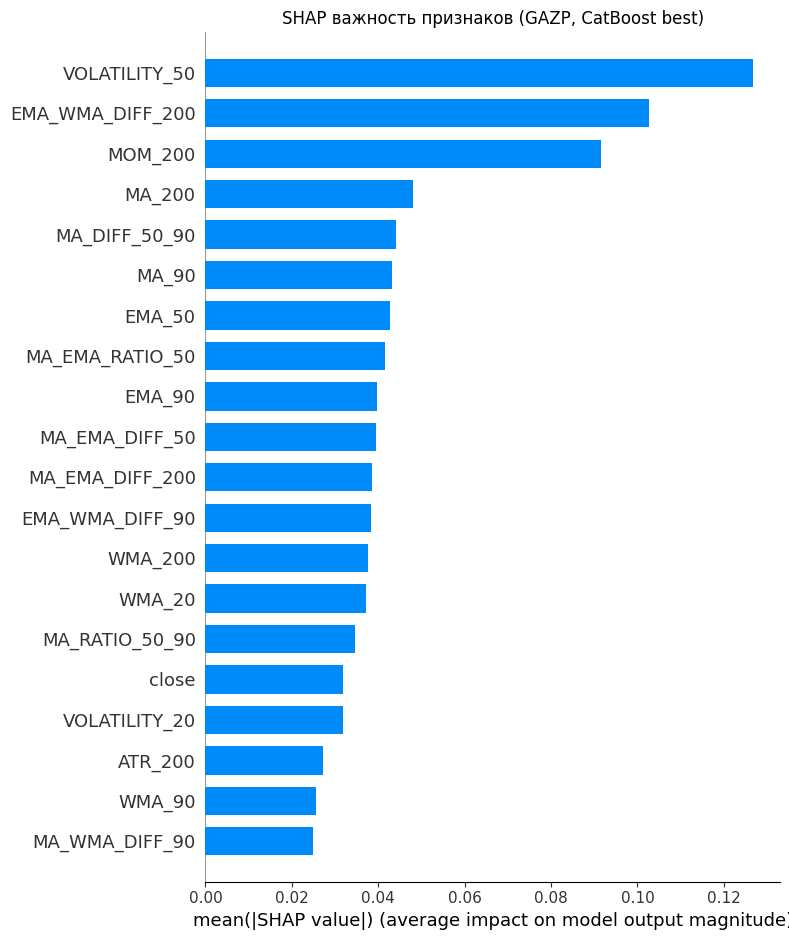

In [ ]:
import shap

best_cat_model_GAZP = CatBoostRegressor(
    depth=8,
    iterations=100,
    l2_leaf_reg=3,
    learning_rate=0.01,
    random_state=13,
    verbose=False
)

best_cat_model_GAZP.fit(X_train_GAZP, y_train_GAZP)

y_pred_GAZP_best = best_cat_model_GAZP.predict(X_test_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP_best, model_name='CatBoost GAZP best + sentiment')

explainer = shap.TreeExplainer(best_cat_model_GAZP)
shap_values = explainer.shap_values(X_test_GAZP)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_GAZP, plot_type='bar', max_display=20, show=False)
plt.title('SHAP важность признаков (GAZP, CatBoost best)')
plt.tight_layout()
plt.show()

Без тональности

In [44]:
y_pred_GAZP_old = train_predict_catboost(X_train_GAZP_old, X_test_GAZP_old, y_train_GAZP_old)
evaluate_regression(y_test_GAZP_old, y_pred_GAZP_old)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 4.7685%
RMSE: 6.0205%
R²: -0.0063
Accuracy направления: 0.6208


{'mae': 4.768516837176906,
 'rmse': 6.020468793046434,
 'r2': -0.006347688972191401,
 'direction_accuracy': 0.6208133971291866}

### 3.4.4 Лукойл

In [39]:
y_pred_LKOH = train_predict_catboost(X_train_LKOH, X_test_LKOH, y_train_LKOH)
evaluate_regression(y_test_LKOH, y_pred_LKOH)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.0785%
RMSE: 3.8159%
R²: -0.1410
Accuracy направления: 0.4737


{'mae': 3.078488276519525,
 'rmse': 3.815903579207555,
 'r2': -0.14101041026408456,
 'direction_accuracy': 0.47368421052631576}

Без тональности

In [45]:
y_pred_LKOH_old = train_predict_catboost(X_train_LKOH_old, X_test_LKOH_old, y_train_LKOH_old)
evaluate_regression(y_test_LKOH_old, y_pred_LKOH_old)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 3.1003%
RMSE: 3.8365%
R²: -0.1534
Accuracy направления: 0.4749


{'mae': 3.1002520206877335,
 'rmse': 3.83653067730937,
 'r2': -0.1533793525580096,
 'direction_accuracy': 0.4748803827751196}

### 3.4.5 Роснефть

In [40]:
y_pred_ROSN = train_predict_catboost(X_train_ROSN, X_test_ROSN, y_train_ROSN)
evaluate_regression(y_test_ROSN, y_pred_ROSN)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 4.0556%
RMSE: 5.0678%
R²: -0.2754
Accuracy направления: 0.4522


{'mae': 4.055605455443862,
 'rmse': 5.067822953570438,
 'r2': -0.2754176981378602,
 'direction_accuracy': 0.45215311004784686}

Без тональности

In [46]:
y_pred_ROSN_old = train_predict_catboost(X_train_ROSN_old, X_test_ROSN_old, y_train_ROSN_old)
evaluate_regression(y_test_ROSN_old, y_pred_ROSN_old)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 4.0426%
RMSE: 5.0746%
R²: -0.2788
Accuracy направления: 0.4593


{'mae': 4.042606098970872,
 'rmse': 5.074619281622139,
 'r2': -0.2788408522145118,
 'direction_accuracy': 0.45933014354066987}

## Вывод

Добавление признака тональности новостей не повлияло на измнение качества предсказаний модели градиентного бустинга с побором гиерпараметров ни на одном из активов

# 4 Визуализация резульататов

## 4.1 Сбер

In [25]:
df_SBER_pred = pd.DataFrame(y_test_SBER)
df_SBER_pred = df_SBER_pred.merge(part_SBER[['begin', 'close']], left_index=True, right_index=True)
df_SBER_pred['predict'] = y_pred_SBER
df_SBER_pred.head()

,target_price_change,begin,predict
3374,-4.187316,2025-03-26 12:00:00,-0.337745
3375,-4.374019,2025-03-26 14:00:00,0.950088
3376,-3.767264,2025-03-26 16:00:00,1.625914
3377,-3.684244,2025-03-26 18:00:00,4.459741
3378,-2.849148,2025-03-27 10:00:00,4.409642


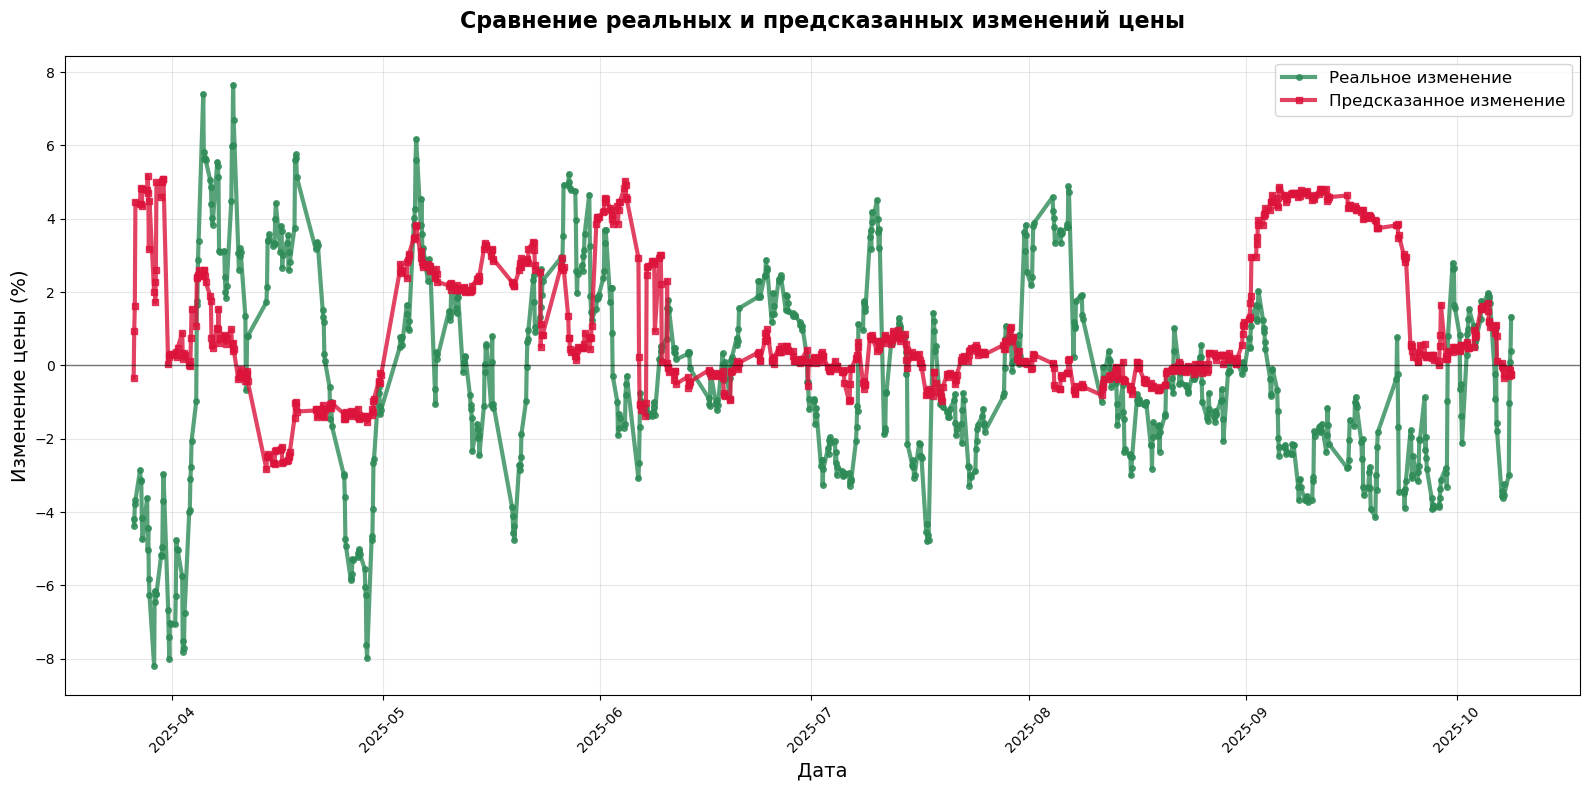

In [26]:
visualize_predictions_comparison(df_SBER_pred)

## 4.2 Газпром

In [53]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
df_GAZP_pred.head()

,target_price_change,begin,close,predict
2363,-2.164857,2025-05-13 18:00:00,146.43,-2.513191
2364,-2.283861,2025-05-14 10:00:00,144.93,-2.171833
2365,-2.684702,2025-05-14 12:00:00,145.64,-2.713499
2366,-2.602740,2025-05-14 14:00:00,146.00,-2.933511
2367,-2.956952,2025-05-14 16:00:00,145.42,-2.759070


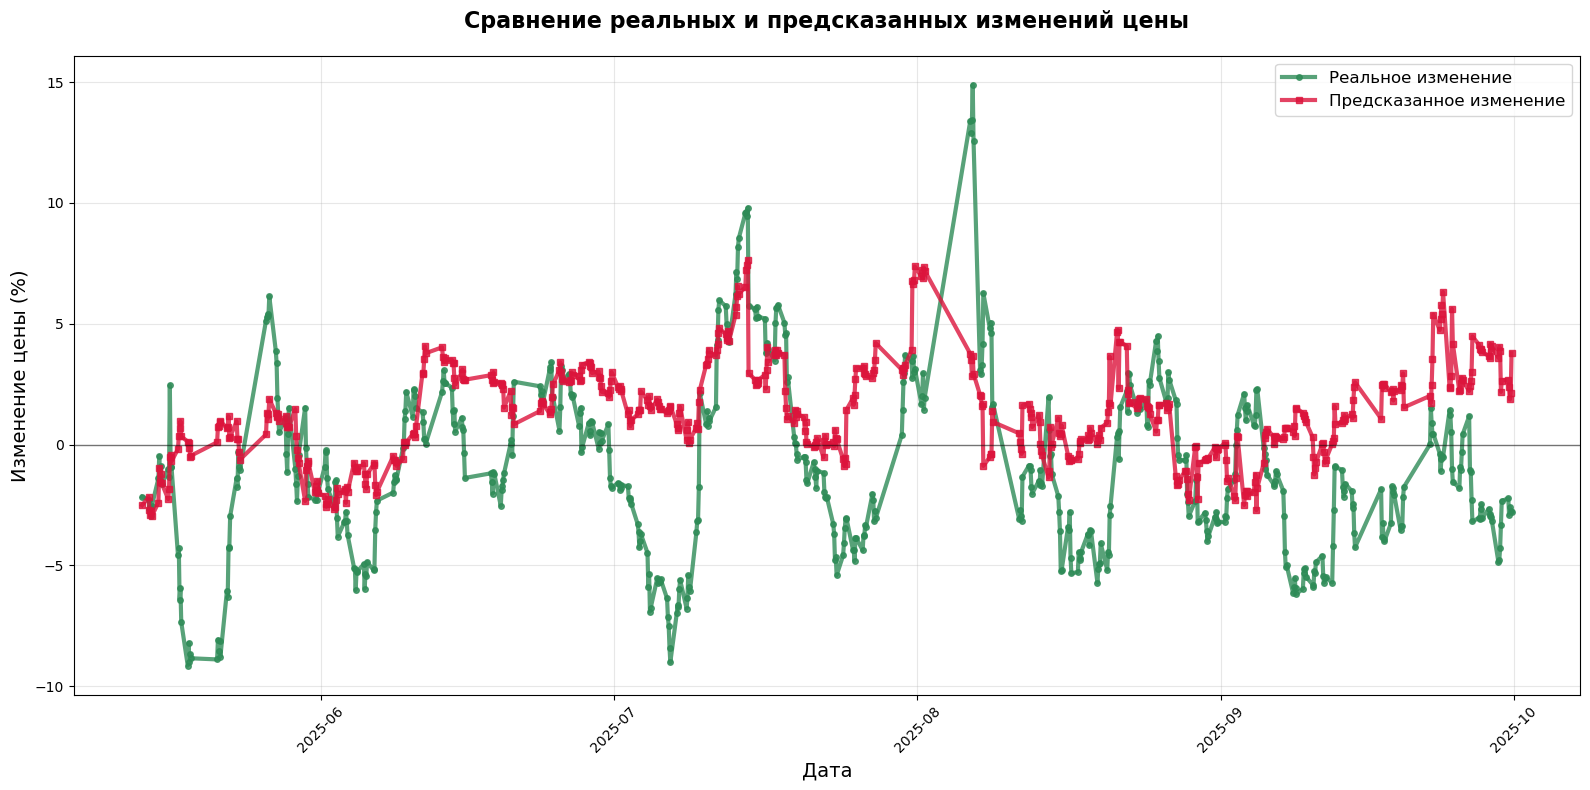

In [54]:
visualize_predictions_comparison(df_GAZP_pred)